In [ ]:
# Block 1: Imports & Config
import os, time, math, copy
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torch.amp import autocast, GradScaler

# ==== CONFIG ====
DATA_MODE = "folders"   # using folder layout
IMAGE_ROOT = "../data"
TRAIN_DIR = os.path.join(IMAGE_ROOT, "train")
TEST_DIR  = os.path.join(IMAGE_ROOT, "test")
OUTPUT_DIR = "/saved_models/baseline_vgg"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_CLASSES   = 7
BATCH_SIZE    = 128
NUM_WORKERS   = 0  # Set to 0 for GPU training (Windows + CUDA issue)
EPOCHS        = 150          # start smaller (can scale to 300)
BASE_LR       = 0.01
WEIGHT_DECAY  = 1e-4
MOMENTUM      = 0.9
DROPOUT_PROB  = 0.5
# Force CUDA GPU explicitly
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cuda:0


In [3]:
# ========== GPU DIAGNOSTICS ==========
print("=" * 60)
print("🔍 GPU DIAGNOSTICS")
print("=" * 60)

# Check CUDA availability
print(f"\n✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ CUDA version: {torch.version.cuda}")
print(f"✓ Number of GPUs: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"✓ Current GPU device: {torch.cuda.current_device()}")
    print(f"✓ GPU name: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU total memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"✓ Device: {DEVICE}")
    
    # Test GPU tensor operation
    test_tensor = torch.randn(100, 100).to(DEVICE)
    print(f"✓ Test tensor device: {test_tensor.device}")
    
    # GPU utilization
    torch.cuda.synchronize()
    print(f"✓ GPU memory allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"✓ GPU memory reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
else:
    print("⚠️  CUDA is NOT available! PyTorch will use CPU.")
    print("   Consider reinstalling PyTorch with CUDA support.")

print("=" * 60)

🔍 GPU DIAGNOSTICS

✓ CUDA available: True
✓ CUDA version: 12.1
✓ Number of GPUs: 1
✓ Current GPU device: 0
✓ GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
✓ GPU total memory: 4.29 GB
✓ Device: cuda:0
✓ Test tensor device: cuda:0
✓ GPU memory allocated: 0.00 GB
✓ GPU memory reserved: 0.00 GB


In [4]:
# Block 2: Dataset & Augmentations
from torchvision.transforms import RandomErasing

class ImageFolderGray(Dataset):
    """Reads grayscale images from folder layout."""
    def __init__(self, root, transform=None):
        self.samples = []
        self.classes = sorted([d.name for d in Path(root).iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        for c in self.classes:
            for f in (Path(root) / c).glob("*"):
                if f.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]:
                    self.samples.append((str(f), self.class_to_idx[c]))
        self.transform = transform

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p, label = self.samples[idx]
        img = Image.open(p).convert("L")
        if self.transform: img = self.transform(img)
        return img, label

# ==== Augmentations ====
train_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=10, translate=(0.2,0.2), scale=(0.8,1.2))
    ], p=0.5),
    transforms.RandomCrop(40),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5]),
    RandomErasing(p=0.5)
])

val_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.CenterCrop(40),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])


In [5]:
# Block 3: Model
class SmallVGG(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_prob=DROPOUT_PROB):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1), nn.ReLU(True), nn.BatchNorm2d(128),
            nn.Conv2d(128,128,3,padding=1), nn.ReLU(True), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1), nn.ReLU(True), nn.BatchNorm2d(256),
            nn.Conv2d(256,256,3,padding=1), nn.ReLU(True), nn.BatchNorm2d(256),
            nn.MaxPool2d(2),

            nn.Conv2d(256,512,3,padding=1), nn.ReLU(True), nn.BatchNorm2d(512),
            nn.Conv2d(512,512,3,padding=1), nn.ReLU(True), nn.BatchNorm2d(512),
            nn.AdaptiveAvgPool2d((2,2)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*2*2, 1024), nn.ReLU(True), nn.Dropout(dropout_prob),
            nn.Linear(1024, 512),    nn.ReLU(True), nn.Dropout(dropout_prob),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def make_model():
    model = SmallVGG(num_classes=NUM_CLASSES)
    return model.to(DEVICE)

# Quick param check
m = make_model()
print("Total params:", sum(p.numel() for p in m.parameters()))

Total params: 7314631


In [6]:
# Block 4: Dataloaders
def get_dataloaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_ds = ImageFolderGray(TRAIN_DIR, transform=train_transform)
    val_ds   = ImageFolderGray(TEST_DIR,  transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=False)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=False)
    test_loader  = val_loader
    return train_loader, val_loader, test_loader

# Quick sanity check
train_loader, val_loader, test_loader = get_dataloaders()
print(f"Train: {len(train_loader)} | Val: {len(val_loader)}")


Train: 225 | Val: 57


In [7]:
# Block 5: Training Utilities
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, total_acc, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(outputs, labels) * bs
        n += bs
    return total_loss/n, total_acc/n

def validate(model, loader, criterion):
    model.eval()
    total_loss, total_acc, n = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast(device_type='cuda'):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            bs = imgs.size(0)
            total_loss += loss.item() * bs
            total_acc  += accuracy_from_logits(outputs, labels) * bs
            n += bs
    return total_loss/n, total_acc/n


In [8]:
# Block 6: Training Loop + Schedulers
def choose_optimizer(model, opt_name="sgd_nesterov", lr=BASE_LR):
    if opt_name == "sgd_nesterov":
        return torch.optim.SGD(model.parameters(), lr=lr,
                               momentum=MOMENTUM, nesterov=True,
                               weight_decay=WEIGHT_DECAY)
    elif opt_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr,
                                weight_decay=WEIGHT_DECAY)
    else:
        raise ValueError(opt_name)

def choose_scheduler(optimizer, sched_name="ReduceLROnPlateau"):
    if sched_name == "ReduceLROnPlateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.75, patience=5)
    elif sched_name == "CosineAnnealing":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=50, eta_min=1e-6)
    else:
        return None

def fit(model, train_loader, val_loader, test_loader=None,
        optimizer_name="sgd_nesterov", scheduler_name="ReduceLROnPlateau",
        epochs=EPOCHS):
    # Force model to CUDA
    model = model.to('cuda:0')
    print(f"✓ Model moved to: {next(model.parameters()).device}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = choose_optimizer(model, optimizer_name, BASE_LR)
    scheduler = choose_scheduler(optimizer, scheduler_name)
    scaler = GradScaler('cuda:0')

    best_val = 0
    for epoch in range(epochs):
        t0 = time.time()
        # Verify model is still on GPU
        assert next(model.parameters()).device.type == 'cuda', "Model not on GPU!"
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_acc = validate(model, val_loader, criterion)

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_acc)
        elif scheduler: scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | "
              f"TrainLoss {train_loss:.4f} | TrainAcc {train_acc:.4f} | "
              f"ValLoss {val_loss:.4f} | ValAcc {val_acc:.4f} | "
              f"Time {time.time()-t0:.1f}s")

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pth"))
            print(f"✅ Saved new best model (ValAcc={val_acc:.4f})")

    if test_loader:
        criterion = nn.CrossEntropyLoss()
        model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pth"), map_location=DEVICE))
        test_loss, test_acc = validate(model, test_loader, criterion)
        print(f"\nFinal Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

    return model

In [12]:
# Block 7: Train
train_loader, val_loader, test_loader = get_dataloaders()
model = make_model()
model = fit(model, train_loader, val_loader, test_loader,
            optimizer_name="sgd_nesterov",
            scheduler_name="ReduceLROnPlateau",
            epochs=50)

✓ Model moved to: cuda:0
Epoch 1/50 | TrainLoss 1.7169 | TrainAcc 0.3008 | ValLoss 1.4805 | ValAcc 0.4281 | Time 73.8s
✅ Saved new best model (ValAcc=0.4281)
Epoch 2/50 | TrainLoss 1.4847 | TrainAcc 0.4207 | ValLoss 1.2961 | ValAcc 0.5116 | Time 33.5s
✅ Saved new best model (ValAcc=0.5116)
Epoch 3/50 | TrainLoss 1.3592 | TrainAcc 0.4795 | ValLoss 1.1732 | ValAcc 0.5525 | Time 32.7s
✅ Saved new best model (ValAcc=0.5525)
Epoch 4/50 | TrainLoss 1.2865 | TrainAcc 0.5122 | ValLoss 1.1111 | ValAcc 0.5797 | Time 32.3s
✅ Saved new best model (ValAcc=0.5797)
Epoch 5/50 | TrainLoss 1.2382 | TrainAcc 0.5282 | ValLoss 1.0861 | ValAcc 0.5837 | Time 38.2s
✅ Saved new best model (ValAcc=0.5837)
Epoch 6/50 | TrainLoss 1.2046 | TrainAcc 0.5452 | ValLoss 1.0675 | ValAcc 0.5894 | Time 37.1s
✅ Saved new best model (ValAcc=0.5894)
Epoch 7/50 | TrainLoss 1.1734 | TrainAcc 0.5552 | ValLoss 1.0390 | ValAcc 0.6067 | Time 40.4s
✅ Saved new best model (ValAcc=0.6067)
Epoch 8/50 | TrainLoss 1.1455 | TrainAcc 0.5

C:\Users\Yasmine Sassi\AppData\Local\Temp\ipykernel_39396\3114049460.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(OUTPU


Final Test Acc: 0.6871 | Test Loss: 0.8898


In [13]:
# Block 8: Fine-Tuning (optional small-LR retrain)
def fine_tune(model_path=os.path.join(OUTPUT_DIR, "best_model.pth"),
              lr=1e-4, extra_epochs=20):
    model = make_model()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    optimizer = torch.optim.SGD(model.parameters(), lr=lr,
                                momentum=MOMENTUM, nesterov=True,
                                weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=extra_epochs, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler('cuda')
    train_loader, val_loader, _ = get_dataloaders()

    for epoch in range(extra_epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_acc = validate(model, val_loader, criterion)
        scheduler.step()
        print(f"[FT] Epoch {epoch+1}/{extra_epochs} | "
              f"TrainAcc {train_acc:.4f} | ValAcc {val_acc:.4f} | "
              f"Time {time.time()-t0:.1f}s")
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "fine_tuned.pth"))
    print("Fine-tuned model saved.")
    return model

In [14]:
# Block 9: Saliency Map Visualization
def generate_saliency(model_path=os.path.join(OUTPUT_DIR, "best_model.pth"),
                      root=TEST_DIR, class_name="Happy", idx_in_class=0,
                      savepath=os.path.join(OUTPUT_DIR, "saliency.png")):
    model = make_model()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # pick an image
    target_dir = os.path.join(root, class_name)
    img_path = sorted(list(Path(target_dir).glob("*")))[idx_in_class]
    img = Image.open(img_path).convert("L")

    prep = transforms.Compose([
        transforms.Resize((48,48)),
        transforms.CenterCrop(40),
        transforms.ToTensor(),
        transforms.Normalize([0.5],[0.5]),
    ])
    x = prep(img).unsqueeze(0).to(DEVICE)
    x.requires_grad = True
    out = model(x)
    score, _ = out.max(1)
    model.zero_grad()
    score.backward()
    sal = x.grad.abs().detach().cpu().squeeze().numpy()
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)

    fig, ax = plt.subplots(1,2, figsize=(6,3))
    ax[0].imshow(img, cmap='gray'); ax[0].axis('off')
    ax[1].imshow(img, cmap='gray'); ax[1].imshow(sal, cmap='jet', alpha=0.5); ax[1].axis('off')
    plt.tight_layout(); plt.savefig(savepath); plt.close()
    print(f"Saved saliency: {savepath}")

# Example:
# generate_saliency(class_name="Happy", idx_in_class=0)


In [15]:
# Block 10: Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

def plot_confusion_matrix(model_path=os.path.join(OUTPUT_DIR, "best_model.pth"),
                          root=TEST_DIR,
                          class_names=None,
                          savepath=os.path.join(OUTPUT_DIR, "confusion_matrix.png")):
    # Load model
    model = make_model()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # Dataset & loader
    ds = ImageFolderGray(root, transform=val_transform)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    if class_names is None:
        class_names = sorted([d.name for d in Path(root).iterdir() if d.is_dir()])

    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast(device_type='cuda'):
                outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Normalized Confusion Matrix (FER2013)")
    plt.tight_layout()
    plt.savefig(savepath)
    plt.close()
    print(f"Confusion matrix saved at: {savepath}")

# Example:
# plot_confusion_matrix(root=TEST_DIR)


In [16]:
# Block 11: Training & Validation Curves
import matplotlib.pyplot as plt

def plot_training_curves(history, savepath=os.path.join(OUTPUT_DIR, "training_curves.png")):
    """
    history should be a dict containing:
      'train_loss', 'train_acc', 'val_loss', 'val_acc'
    Returned by fit() in Block 6/7.
    """
    if not isinstance(history, dict):
        print("⚠️ Expected dict with train/val losses & accuracies.")
        return
    
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(10,4))

    # ---- Accuracy ----
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_acc'], label="Train Acc")
    plt.plot(epochs, history['val_acc'], label="Val Acc")
    plt.xlabel("Epochs"); plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend(); plt.grid(True, alpha=0.3)

    # ---- Loss ----
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_loss'], label="Train Loss")
    plt.plot(epochs, history['val_loss'], label="Val Loss")
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(savepath)
    plt.close()
    print(f"📈 Saved training curves: {savepath}")

# Example (after training):
# plot_training_curves(history)


C:\Users\Yasmine Sassi\AppData\Local\Temp\ipykernel_39396\3181021614.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

[FT] Epoch 1/40 | TrainAcc 0.7102 | ValAcc 0.6921 | Time 32.7s
[FT] Epoch 2/40 | TrainAcc 0.7155 | ValAcc 0.6934 | Time 34.6s
[FT] Epoch 3/40 | TrainAcc 0.7170 | ValAcc 0.6925 | Time 32.6s
[FT] Epoch 4/40 | TrainAcc 0.7178 | ValAcc 0.6917 | Time 32.3s
[FT] Epoch 5/40 | TrainAcc 0.7217 | ValAcc 0.6928 | Time 34.2s
[FT] Epoch 6/40 | TrainAcc 0.7207 | ValAcc 0.6924 | Time 34.7s
[FT] Epoch 7/40 | TrainAcc 0.7233 | ValAcc 0.6934 | Time 36.3s
[FT] Epoch 8/40 | TrainAcc 0.7221 | ValAcc 0.6943 | Time 35.5s
[FT] Epoch 9/40 | TrainAcc 0.7208 | ValAcc 0.6943 | Time 35.9s
[FT] Epoch 10/40 | TrainAcc 0.7220 | ValAcc 0.6939 | Time 33.7s
[FT] Epoch 11/40 | TrainAcc 0.7245 | ValAcc 0.6941 | Time 35.0s
[FT] Epoch 12/40 | TrainAcc 0.7254 | ValAcc 0.6938 | Time 32.7s
[FT] Epoch 13/40 | TrainAcc 0.7271 | ValAcc 0.6950 | Time 33.8s
[FT] Epoch 14/40 | TrainAcc 0.7270 | ValAcc 0.6964 | Time 35.6s
[FT] Epoch 15/40 | TrainAcc 0.7248 | ValAcc 0.6946 | Time 37.6s
[FT] Epoch 16/40 | TrainAcc 0.7250 | ValAcc 0.696

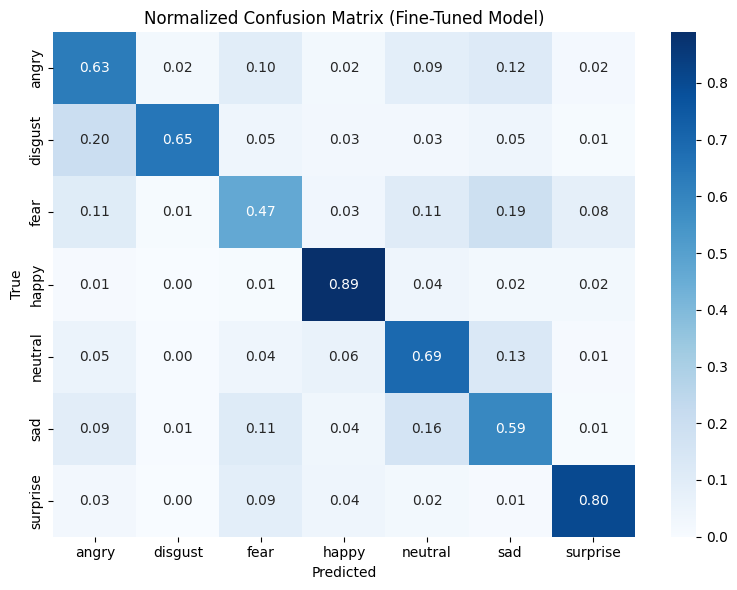


✅ Confusion matrix saved at: ../data/output\confusion_matrix_finetuned.png


In [17]:
# === 1️⃣ Fine-tune the best checkpoint ===
# This will load 'best_model.pth', train a bit more at a lower LR, and save 'fine_tuned.pth'
model_ft = fine_tune(model_path=os.path.join(OUTPUT_DIR, "best_model.pth"),
                     lr=1e-4, extra_epochs=40)

# === 2️⃣ Evaluate fine-tuned model on test set ===
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the fine-tuned model for evaluation
model_ft.eval()
test_ds = ImageFolderGray(TEST_DIR, transform=val_transform)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model_ft(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === 3️⃣ Classification Report ===
class_names = sorted([d.name for d in Path(TEST_DIR).iterdir() if d.is_dir()])
print("\n📋 Final Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

# === 4️⃣ Confusion Matrix Plot ===
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Fine-Tuned Model)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_finetuned.png"))
plt.show()
print(f"\n✅ Confusion matrix saved at: {os.path.join(OUTPUT_DIR, 'confusion_matrix_finetuned.png')}")


In [18]:
generate_saliency(class_name="Happy", idx_in_class=0)

C:\Users\Yasmine Sassi\AppData\Local\Temp\ipykernel_39396\2735653304.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

Saved saliency: ../data/output\saliency.png
